# Publish Rate Benchmark Analysis
### How do protocols perform under increasing message load?
---

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR   = os.path.join('results', 'rate')
N_NODES       = 1000
K             = 32
PUBLISH_RATES = [1, 2, 4]#, 8, 16]#, 32, 64]
PROTOCOLS     = ['kadcast', 'kadrlnc', 'optimump2p']
COLORS        = {'kadcast': '#E63946', 'kadrlnc': '#2A9D8F', 'optimump2p': '#E9C46A'}
LABELS        = {'kadcast': 'Kadcast', 'kadrlnc': 'KadRLNC', 'optimump2p': 'OPTIMUMP2P'}
MARKERS       = {'kadcast': 'o', 'kadrlnc': 's', 'optimump2p': '^'}

plt.rcParams.update({
    'figure.dpi': 150, 'font.family': 'monospace',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
print('Setup complete.')

Setup complete.


In [2]:
# Load all CSVs
def load_rate_data(results_dir, protocols, rates):
    deliveries = {p: {} for p in protocols}
    shards     = {p: {} for p in protocols}
    for p in protocols:
        for rate in rates:
            d_files = sorted(glob.glob(os.path.join(results_dir, f'{p}_*_{rate}_deliveries.csv')))
            s_files = sorted(glob.glob(os.path.join(results_dir, f'{p}_*_{rate}_shards.csv')))
            d_frames, s_frames = [], []
            for path in d_files:
                seed = int(os.path.basename(path).split('_')[1])
                df   = pd.read_csv(path); df['seed'] = seed; d_frames.append(df)
            for path in s_files:
                seed = int(os.path.basename(path).split('_')[1])
                df   = pd.read_csv(path); df['seed'] = seed; s_frames.append(df)
            deliveries[p][rate] = pd.concat(d_frames, ignore_index=True) if d_frames else pd.DataFrame()
            shards[p][rate]     = pd.concat(s_frames, ignore_index=True) if s_frames else pd.DataFrame()
        print(f'{p}: loaded {len(rates)} rates')
    return deliveries, shards

deliveries, shards = load_rate_data(RESULTS_DIR, PROTOCOLS, PUBLISH_RATES)

# Compute relative delivery time per block (time_ms - inject_time_ms)
for p in PROTOCOLS:
    for rate in PUBLISH_RATES:
        df = deliveries[p][rate]
        if not df.empty and 'inject_time_ms' in df.columns:
            df['rel_time'] = df['time_ms'] - df['inject_time_ms']
print('Data loaded.')

kadcast: loaded 3 rates
kadrlnc: loaded 3 rates
optimump2p: loaded 3 rates
Data loaded.


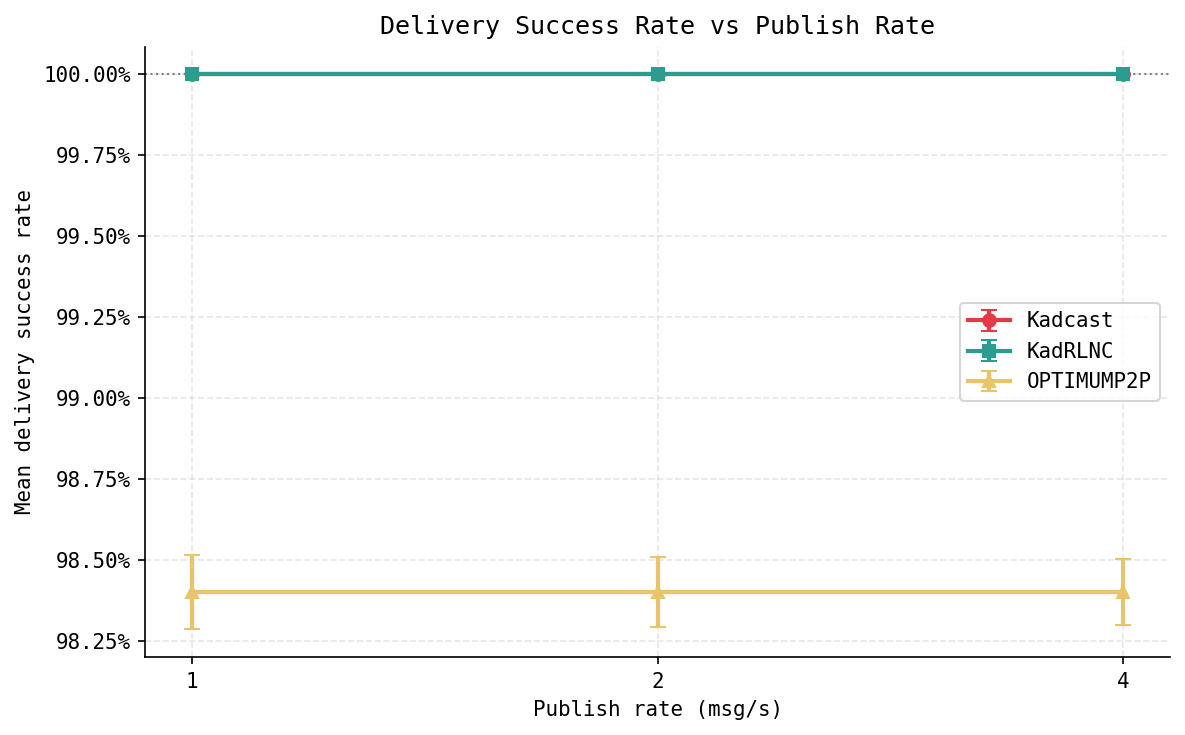

In [3]:
# 1. Delivery success rate vs publish rate
# For each rate, compute mean fraction of N_NODES that decoded each tracked block.

fig, ax = plt.subplots(figsize=(8, 5))

for p in PROTOCOLS:
    means, stds = [], []
    for rate in PUBLISH_RATES:
        df = deliveries[p][rate]
        if df.empty: means.append(np.nan); stds.append(0); continue
        per_block = df.groupby(['seed','block_id'])['node_id'].count() / N_NODES
        means.append(per_block.mean())
        stds.append(per_block.std())
    ax.errorbar(PUBLISH_RATES, means, yerr=stds, color=COLORS[p],
                marker=MARKERS[p], lw=2, capsize=4, label=LABELS[p])

ax.axhline(1.0, color='grey', lw=1, ls=':')
ax.set_xlabel('Publish rate (msg/s)')
ax.set_ylabel('Mean delivery success rate')
ax.set_title('Delivery Success Rate vs Publish Rate')
ax.set_xscale('log', base=2)
ax.set_xticks(PUBLISH_RATES); ax.set_xticklabels([str(r) for r in PUBLISH_RATES])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(); plt.tight_layout()
plt.savefig('figures/rate/rate_success.png', bbox_inches='tight'); plt.show()

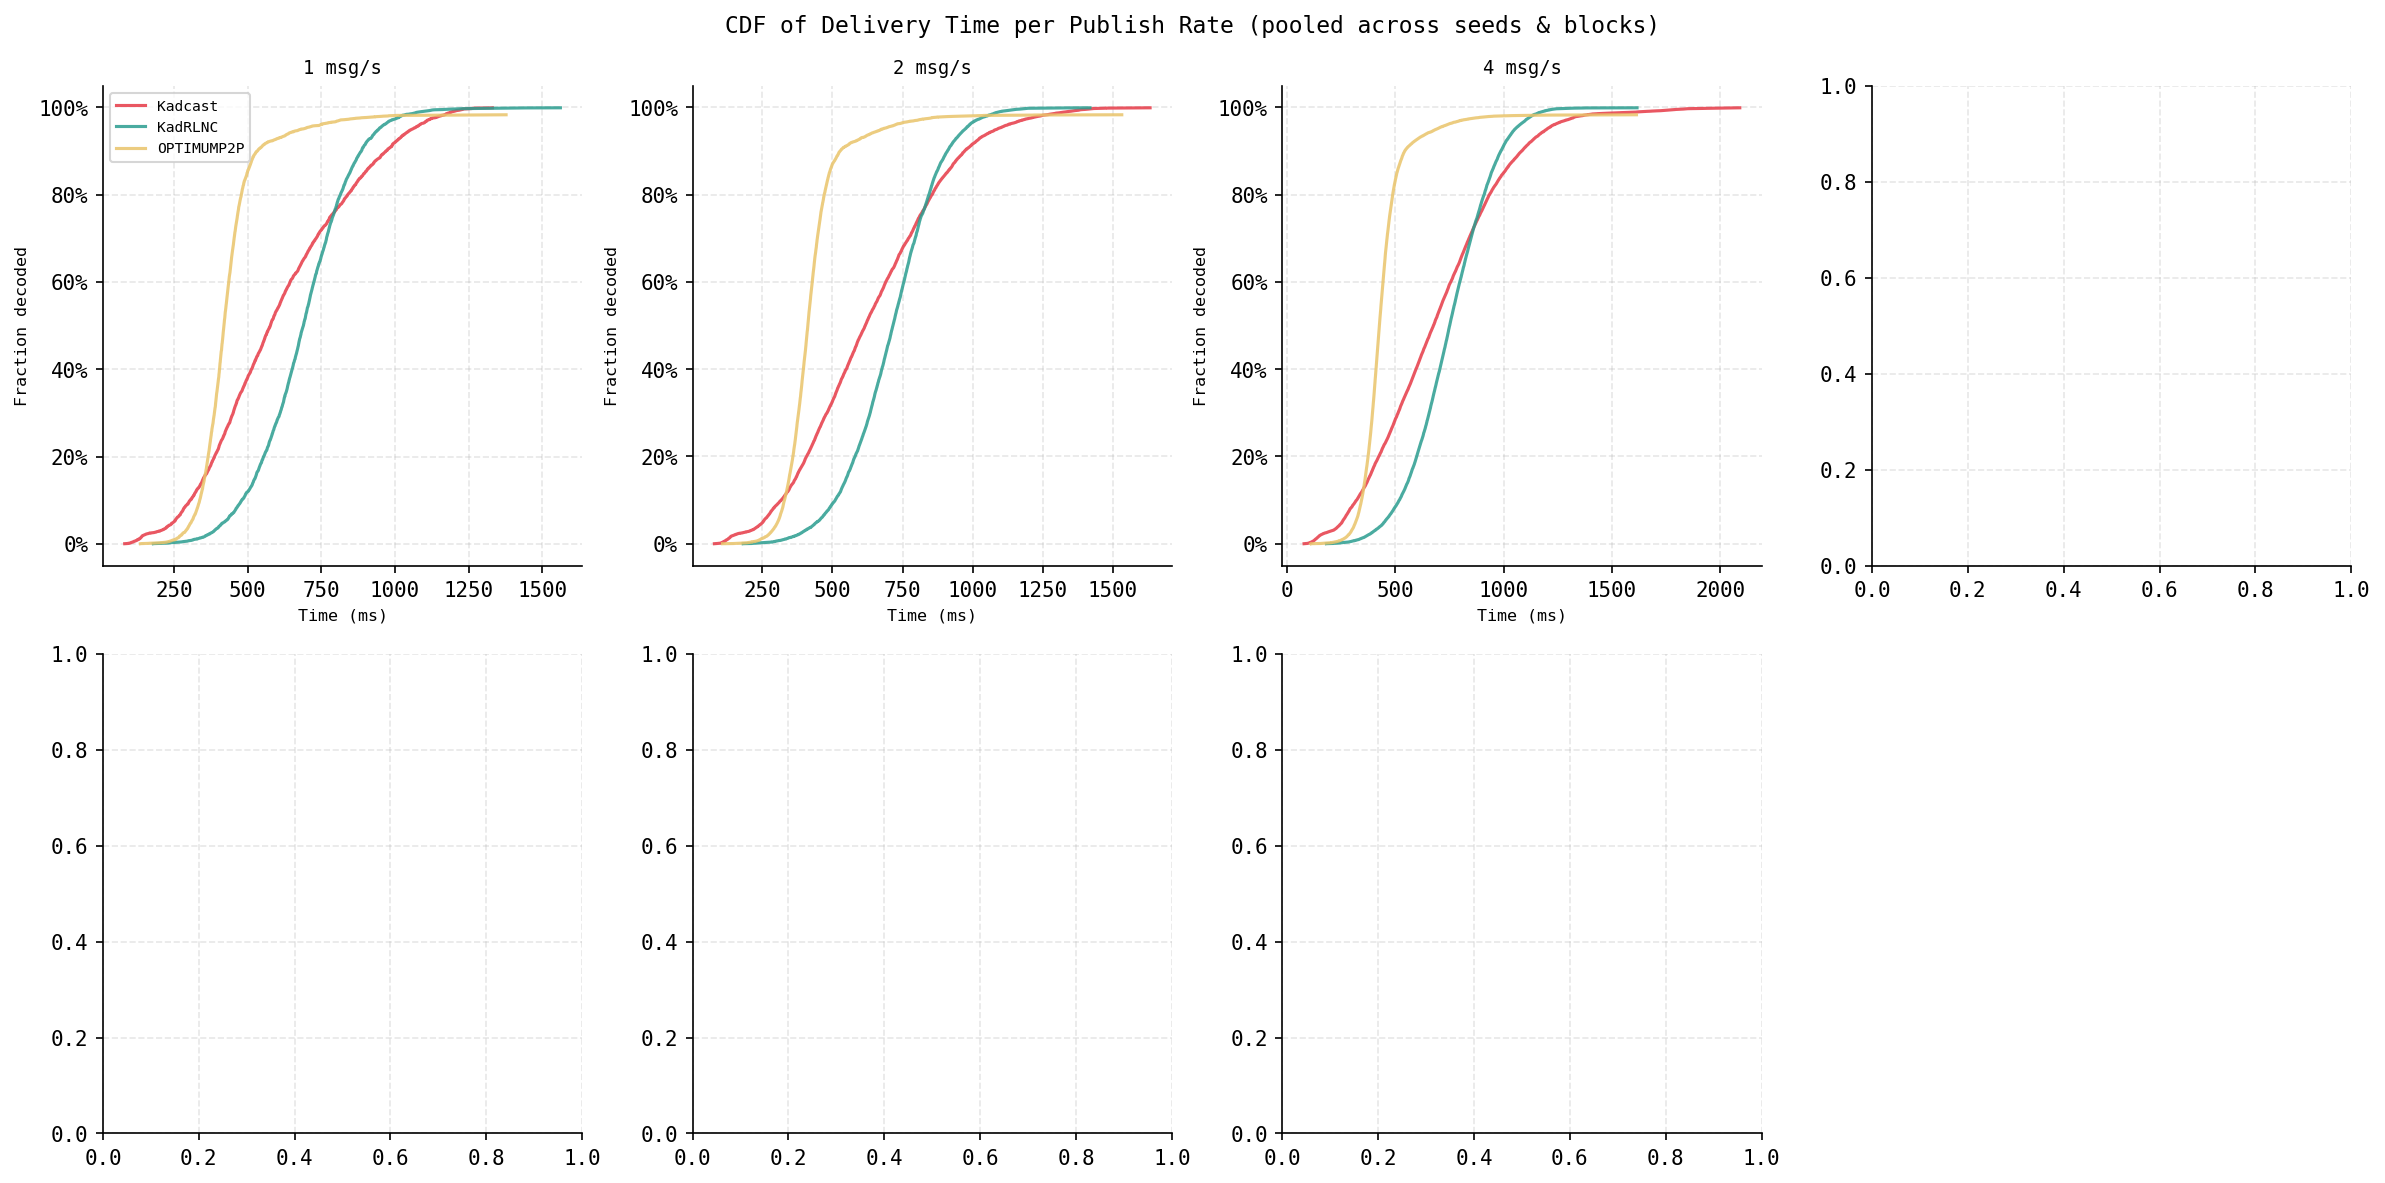

In [4]:
# 2. CDF of relative delivery time — one subplot per publish rate
# Shows how delivery speed degrades under increasing load.

n_rates = len(PUBLISH_RATES)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, rate in enumerate(PUBLISH_RATES):
    ax = axes[idx]
    for p in PROTOCOLS:
        df = deliveries[p][rate]
        if df.empty: continue
        all_times = df[df['rel_time'] > 0]['rel_time'].values
        if len(all_times) == 0: continue
        sorted_t  = np.sort(all_times)
        frac      = np.arange(1, len(sorted_t)+1) / (N_NODES * df.groupby(['seed','block_id']).ngroups)
        ax.plot(sorted_t, np.minimum(frac * N_NODES / N_NODES, 1),
                color=COLORS[p], lw=1.5, label=LABELS[p], alpha=0.85)
    ax.set_title(f'{rate} msg/s', fontsize=9)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Fraction decoded', fontsize=8)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    if idx == 0: ax.legend(fontsize=7)

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('CDF of Delivery Time per Publish Rate (pooled across seeds & blocks)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/rate/rate_cdfs.png', bbox_inches='tight'); plt.show()

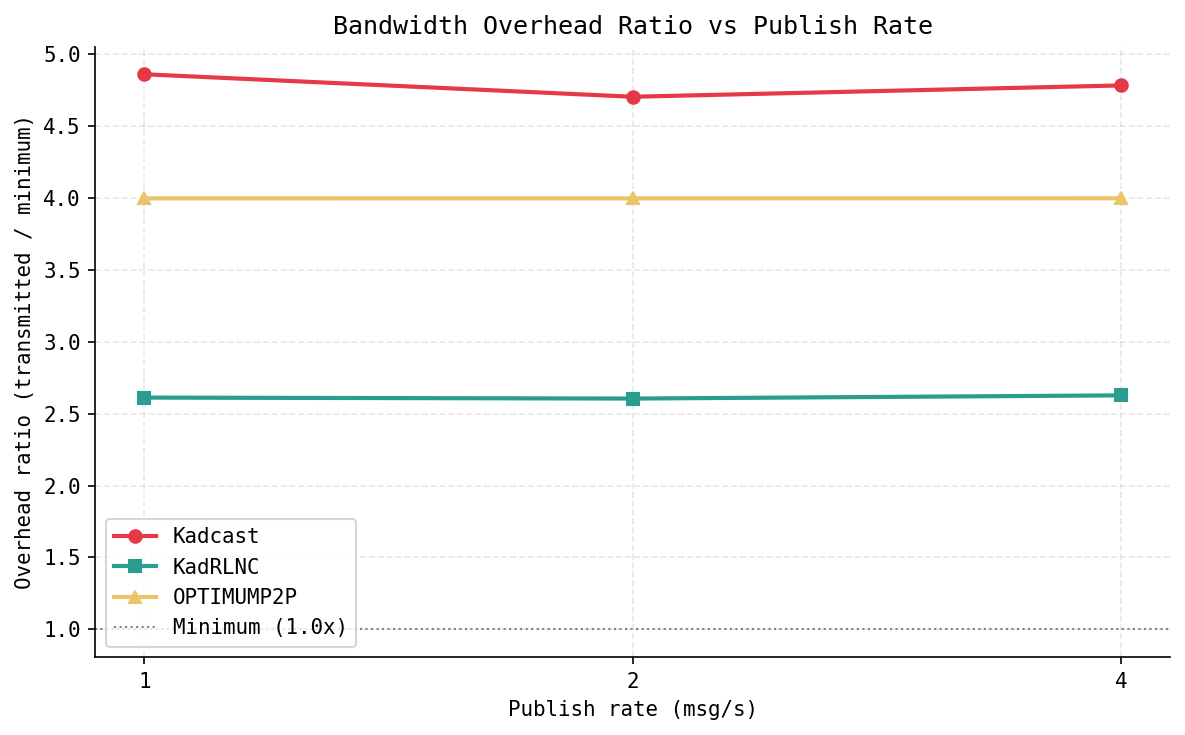

In [5]:
# 3. Bandwidth overhead ratio vs publish rate
fig, ax = plt.subplots(figsize=(8, 5))

for p in PROTOCOLS:
    ratios = []
    for rate in PUBLISH_RATES:
        df_s = shards[p][rate]; df_d = deliveries[p][rate]
        if df_s.empty or df_d.empty: ratios.append(np.nan); continue
        decoded = df_d.groupby(['seed','block_id'])['node_id'].count().reset_index()
        decoded.columns = ['seed','block_id','decoded_count']
        merged = df_s.merge(decoded, on=['seed','block_id'])
        ratios.append((merged['shard_count'] / (K * merged['decoded_count'])).mean())
    ax.plot(PUBLISH_RATES, ratios, color=COLORS[p], marker=MARKERS[p], lw=2, label=LABELS[p])

ax.axhline(1.0, color='grey', lw=1, ls=':', label='Minimum (1.0x)')
ax.set_xlabel('Publish rate (msg/s)')
ax.set_ylabel('Overhead ratio (transmitted / minimum)')
ax.set_title('Bandwidth Overhead Ratio vs Publish Rate')
ax.set_xscale('log', base=2)
ax.set_xticks(PUBLISH_RATES); ax.set_xticklabels([str(r) for r in PUBLISH_RATES])
ax.legend(); plt.tight_layout()
plt.savefig('figures/rate/rate_overhead.png', bbox_inches='tight'); plt.show()

In [6]:
# Summary table
rows = []
for p in PROTOCOLS:
    for rate in PUBLISH_RATES:
        df_d = deliveries[p][rate]
        if df_d.empty: continue
        per_block = df_d.groupby(['seed','block_id'])['node_id'].count() / N_NODES
        df_s = shards[p][rate]
        decoded = df_d.groupby(['seed','block_id'])['node_id'].count().reset_index()
        decoded.columns = ['seed','block_id','decoded_count']
        merged  = df_s.merge(decoded, on=['seed','block_id']) if not df_s.empty else pd.DataFrame()
        overhead = (merged['shard_count'] / (K * merged['decoded_count'])).mean() if not merged.empty else float('nan')
        rows.append({'Protocol': LABELS[p], 'Rate (msg/s)': rate,
                     'Success rate': f'{per_block.mean():.3f}',
                     'Overhead': f'{overhead:.2f}x'})
pd.DataFrame(rows).set_index(['Protocol','Rate (msg/s)'])

Success rate Overhead
Protocol   Rate (msg/s)                      
Kadcast    1                   1.000    4.86x
           2                   1.000    4.70x
           4                   1.000    4.78x
KadRLNC    1                   1.000    2.61x
           2                   1.000    2.61x
           4                   1.000    2.63x
OPTIMUMP2P 1                   0.984    4.00x
           2                   0.984    4.00x
           4                   0.984    4.00x